<a href="https://colab.research.google.com/github/johanhoffman/DD2365/blob/main/Euler-equations-compressible-flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Euler equations for compressible flow**
**Johan Hoffman**

# **Abstract**

This short report show an example on how to use FEniCS to solve the Euler equations using FEM, which is used in the course DD2365 Advanced Computation in Fluid Mechanics, at the KTH Royal Institute of Technology.

[DD2365 course website.](https://www.kth.se/social/course/DD2365/)

# **About the code**

In [1]:
# This program is an example file for the course
# DD2365 Advanced Computation in Fluid Mechanics,
# KTH Royal Institute of Technology, Stockholm, Sweden,

# Copyright (C) 2021 Johan Hoffman (jhoffman@kth.se)

# This file is part of the course DD2365 Advanced Computation in Fluid Mechanics
# KTH Royal Institute of Technology, Stockholm, Sweden
#
# This is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License v2.

# This template is maintained by Johan Hoffman
# Please report problems to jhoffman@kth.se

# **Set up environment**

In [2]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# **Introduction**

For density $\rho$, momentum $m$, and total energy $E$, the Euler equations take the form

$
\begin{eqnarray}
\dot \rho + \nabla \cdot (u \rho) = 0, \\
\dot m + \nabla \cdot (u m) + \nabla p = f, \\
\dot E + \nabla \cdot (u E) + \nabla \cdot(up)= 0,
\end{eqnarray}
$

together with suitable initial and boundary conditions.

Here velocity is given by

$u = \frac{m}{\rho},$

and the total energy is the sum of kinetic energy and internal energy,

$E = \rho |u|^2/2 + \rho e,$

and $f$ is a given force.

We define the adiabatic index  

$\gamma = \frac{c_p}{c_v},$

where $c_p$ and $c_v$ are the specific heats.  

For an ideal gas, we get the pressure $p$ from the gas law

$p=\rho R T$,

with $R$ the ideal gas constant and $T$ is the temperature

Assuming also a caloric perfect gas, the specific heats $c_p$ and $c_v$ are constant, and the internal energy density is given by

$\rho e=\rho c_v T.$

The assumption of an ideal gas (and an assumption of no intermolecular potential energy contributions) further gives that

$R = c_p-c_v= c_v(\gamma - 1),$

so that the pressure is given by

$p = \rho R T = \rho c_v(\gamma - 1) T= (\gamma -1)\rho e,$

with the internal energy,

$e = \frac{E}{\rho} - \frac{\vert u\vert^2}{2}.$

Under these assumptions, the speed of sound is given by

$c = \sqrt{\gamma \frac{p}{\rho}}= \sqrt{\gamma(\gamma-1)e},$

and the Mach number,

$M = \frac{\vert u\vert }{c}.$

Here we present a FEniCS implementation of a stabilized finite element method to solve the Euler equations in 2D. The solution is visualized using FEniCS plotting functions, and is also exported as pvd-files which can be visualized in Paraview.

# **Method**

**Define domain and mesh**

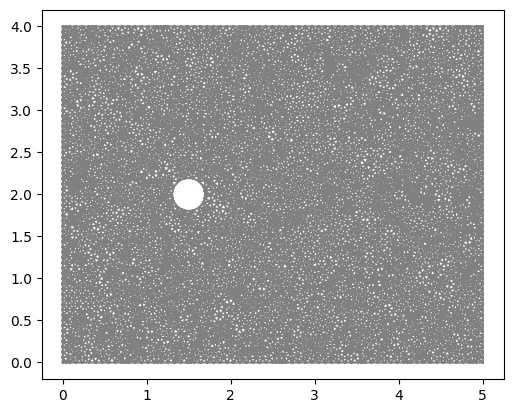

In [3]:
# Define length scale
L_ref = 1.0

# Define rectangular domain
L = 5.0
H = 4.0

# Model diameter
MD = 0.4

# Define circle
xc = 1.5
yc = 0.5*H
rc = 0.5*MD

# Generate mesh (examples with and without a hole in the mesh)
resolution = 64
#mesh = RectangleMesh(Point(0.0, 0.0), Point(L, H), L*resolution, H*resolution)
mesh = generate_mesh(Rectangle(Point(0.0,0.0), Point(L,H)) - Circle(Point(xc,yc),rc), resolution)

# Local mesh refinement (specified by a cell marker)
no_levels = 0
for i in range(0,no_levels):
  cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
  for cell in cells(mesh):
    cell_marker[cell] = False
    p = cell.midpoint()
    if p.distance(Point(xc, yc)) < 1.0:
        cell_marker[cell] = True
  mesh = refine(mesh, cell_marker)

# Define subdomains (for boundary conditions)
class Left(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], 0.0)

class Right(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], L)

class Lower(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], 0.0)

class Upper(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], H)

class Object(SubDomain):
    def inside(self, x, on_boundary, L=L, H=H):
        return on_boundary and (not near(x[0], 0.0)) and (not near(x[0], L)) and (not near(x[1], 0.0)) and (not near(x[1], H))

left = Left()
right = Right()
lower = Lower()
upper = Upper()
object = Object()

# Define mesh functions (for boundary conditions)
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1)
boundaries.set_all(0)
left.mark(boundaries, 1)
right.mark(boundaries, 2)
lower.mark(boundaries, 3)
upper.mark(boundaries, 4)
object.mark(boundaries, 5)

# Define measure for boundary integration
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

plt.figure()
plot(mesh)
plt.show()

**Define physics model**

In [4]:
# Adiabatic index gamma = cp/cv (gamma = 1.4 for air)
gamma = 1.4

# Specific gas constant [J/(kg*K)] (R = 287 for air)
R_constant = 287

# Specific heat at constant pressure cv [J/(kg*K)] (cv = 717.5 for air)
cv = R_constant/(gamma - 1.0)

# Free stream flow data (used as boundary data)
r_fs = 1.225 # [kg/m3]
Temp_fs = 290 # [K]
u_fs = 500 # [m/s]

print("Free stream density [kg/m3]:", r_fs)
print("Free stream temperature [T]:", Temp_fs)
print("Free stream velocity [m/s]:", u_fs)

# Momentum [kg/(s*m2)]
m_fs = u_fs*r_fs

# Speed of sound [m/s]
c_fs = sqrt(gamma*R_constant*Temp_fs)

# Mach number [nondimensional]
M_fs = u_fs/c_fs
print("Mach number (free stream):", M_fs)

# Internal energy density [J/kg]
e_fs = cv*Temp_fs

# Total energy [J/m^3]
E_fs = r_fs*(e_fs + 0.5*u_fs*u_fs)

# Canonical nondimensional form – reference normalizations
r_ref = 1.225 # [kg/m3] – sea-level density
u_ref = 340.3 # [m/3] – sea-level speed of sound
m_ref = r_ref*u_ref
E_ref = r_ref*u_ref*u_ref
p_ref = r_ref*u_ref*u_ref

# Free stream pressure
p_fs = r_fs*Temp_fs*R_constant
print("Free stream pressure [kg/(m*s)]:", p_fs)
print("Free stream pressure (nondimensional):", p_fs/p_ref)

# Length of time interval [non-dimeninsional]
T = 10.0
T_ref = L_ref/u_ref # reference time normaization [s]
print("Time interval length [s]:", T*T_ref)

Free stream density [kg/m3]: 1.225
Free stream temperature [T]: 290
Free stream velocity [m/s]: 500
Mach number (free stream): 1.4647585414197535
Free stream pressure [kg/(m*s)]: 101956.75
Free stream pressure (nondimensional): 0.7187138209021805
Time interval length [s]: 0.029385836027034967


**Define finite element approximation spaces**

In [5]:
# Generate finite element spaces (for density, momentum, total energy)
R = FunctionSpace(mesh, "Lagrange", 1)
V = VectorFunctionSpace(mesh, "Lagrange", 1)
Q = FunctionSpace(mesh, "Lagrange", 1)

# Define trial and test functions
r = TrialFunction(R)
m = TrialFunction(V)
E = TrialFunction(Q)
d = TestFunction(R)
v = TestFunction(V)
q = TestFunction(Q)

**Define boundary conditions**

In [6]:
# Define boundary conditions
class DirichletBoundaryLower(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], 0.0)

class DirichletBoundaryUpper(SubDomain):
    def inside(self, x, on_boundary, H=H):
        return on_boundary and near(x[1], H)

class DirichletBoundaryLeft(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0)

class DirichletBoundaryRight(SubDomain):
    def inside(self, x, on_boundary, L=L):
        return on_boundary and near(x[0], L)

class DirichletBoundaryObjects(SubDomain):
    def inside(self, x, on_boundary, L=L, H=H):
        return on_boundary and (not near(x[0], 0.0)) and (not near(x[0], L)) and (not near(x[1], 0.0)) and (not near(x[1], H))

dbc_lower = DirichletBoundaryLower()
dbc_upper = DirichletBoundaryUpper()
dbc_left = DirichletBoundaryLeft()
dbc_right = DirichletBoundaryRight()
dbc_objects = DirichletBoundaryObjects()

# Nondimensional inflow momentum: m = m_fs/m_ref
m_in = m_fs/m_ref
m_in_vec = as_vector([m_in, 0.0])

bcm_in0 = DirichletBC(V.sub(0), m_in, dbc_left)
bcm_in1 = DirichletBC(V.sub(1), 0.0, dbc_left)
bcm_upp0 = DirichletBC(V.sub(0), 0.0, dbc_upper)
bcm_upp1 = DirichletBC(V.sub(1), 0.0, dbc_upper)
bcm_low0 = DirichletBC(V.sub(0), 0.0, dbc_lower)
bcm_low1 = DirichletBC(V.sub(1), 0.0, dbc_lower)
#bcm_obj0 = DirichletBC(V.sub(0), 0.0, dbc_objects)
#bcm_obj1 = DirichletBC(V.sub(1), 0.0, dbc_objects)

# Slip boundary condition
#V_slip = FunctionSpace(mesh, "CG", 1)
#bcm_slip_0 = Function(V_slip)
#bcm_slip_1 = Function(V_slip)

#bcm_obj0 = DirichletBC(V.sub(0), bcm_slip_0, dbc_objects)
#bcm_obj1 = DirichletBC(V.sub(1), bcm_slip_1, dbc_objects)
#bcm_slip = [bcm_obj0, bcm_obj1]

# Nondimensional inflow density: r = r_fs/r_ref
r_in = r_fs/r_ref
bcr_in = DirichletBC(R, r_in, dbc_left)

# Nondimensional inflow total energy: E = E_fs/E_ref
E_in = E_fs/E_ref
bcE_in = DirichletBC(Q, E_in, dbc_left)

# Inflow boundary conditions (based on characteristics)
#bcm = [bcm_in0, bcm_in1, bcm_upp1, bcm_low1, bcm_obj0, bcm_obj1]
if M_fs > 1.0:
  bcm = [bcm_in0, bcm_in1, bcm_upp1, bcm_low1]
else:
  bcm = [bcm_in0, bcm_upp1, bcm_low1]
bcr = [bcr_in]
bcE = [bcE_in]

# Approximate facet normal in a suitable space using projection
#n = FacetNormal(mesh)
#V_normal = VectorFunctionSpace(mesh, "CG", 1)
#u_ = TrialFunction(V_normal)
#v_ = TestFunction(V_normal)
#a = inner(u_,v_)*ds
#l = inner(n, v_)*ds
#A = assemble(a, keep_diagonal=True)
#L = assemble(l)

#A.ident_zeros()
#node_normal = Function(V_normal)

#solve(A, node_normal.vector(), L)

# Plot the normal field
#import matplotlib.pyplot as plt
#plt.figure()
#plot(node_normal, title="Node-Based Normal Field")
#plt.show()

# **Results**

**Define method parameters**

In [7]:
# Define iteration functions
# *0 solution from previous time step
# *1 linearized solution at present time step
r0 = Function(R)
m0 = Function(V)
E0 = Function(Q)
r1 = Function(R)
m1 = Function(V)
E1 = Function(Q)

# Define lower threshold for density
eps_cav = 1.0e-6

# Set parameters for nonlinear and linear solvers
num_nnlin_iter = 5
prec = "amg" if has_krylov_solver_preconditioner("amg") else "default"

# Time step length
CFL = 1.0
u_in = m_in/r_in
c_in = sqrt(gamma*(gamma-1.0)*(E_in/r_in - 0.5*u_in*u_in))
dt = CFL*mesh.hmin()/(u_in + c_in)

**Define variational problem**

In [8]:
# Define variational problem

# Mean velocities for alpha-method time stepping
# alpha_dt = 0.0 corresponds to explicit Euler time stepping
# alpha_dt = 0.5 corresponds to trapozoidal method
# alpha_dt = 1.0 corresponds to implicit Euler time stepping
alpha_dt = 0.7

rm = alpha_dt*r + (1.0-alpha_dt)*r0
mm = alpha_dt*m + (1.0-alpha_dt)*m0
Em = alpha_dt*E + (1.0-alpha_dt)*E0

rm1 = alpha_dt*r1 + (1.0-alpha_dt)*r0
mm1 = alpha_dt*m1 + (1.0-alpha_dt)*m0
Em1 = alpha_dt*E1 + (1.0-alpha_dt)*E0

u0 = m0/(r0 + eps_cav)
u1 = m1/(r1 + eps_cav)
um1 = alpha_dt*u1 + (1.0-alpha_dt)*u0

# Pressure [nondimensional]
p1 = (gamma - 1.0)*(E1 - 0.5*inner(m1,m1)/(r1 + eps_cav))

# Speed of sound [nondimensional]
c = sqrt(gamma*(gamma-1.0)*(E1/r1 - 0.5*inner(u1, u1)))

# Mach number [nondimensional]
Mach = sqrt(inner(u1, u1))/c

# Outflow boundary condition
p_out = conditional(lt(Mach, Constant(1.0)), p_fs/p_ref, Constant(0.0))

# Facet normal vector
normal = FacetNormal(mesh)

# Local mesh size [nondimensional]
h = CellDiameter(mesh);

# Stabilization parameters
u_mag = sqrt(dot(u1,u1))
C1 = 1.0
d1 = C1/sqrt((pow(1.0/dt,2.0) + pow(u_mag/h,2.0)))

# Parameters for penalty boundary conditions
C_alpha = 1.0e2
alpha_penalty = C_alpha/h

# Residuals
res_r = (r1 - r0)/dt + div(u1)*r1 + inner(grad(r1), u1)
res_m = (m1 - m0)/dt + div(u1)*m1 + grad(m1)*u1 + grad(p1)
res_E = (E1 - E0)/dt + div(u1)*E1 + inner(grad(E1), u1) + div(u1)*p1 + inner(grad(p1), u1)

# Smagorinsky model (simplified)
#C_t = 1.0e-2
#
#nu_turb = h
#nu_turb = C_t*h*h*sqrt(inner(grad(um1), grad(um1)))
#nu_turb = C_stab*h*h*sqrt(res_r*res_r + inner(res_m, res_m) + res_E*res_E)

# Shock-capturing stabilization
C_stab = 1.0

nu_r = C_stab*h*h*sqrt(res_r*res_r)/r_in
nu_m = C_stab*h*h*sqrt(inner(res_m, res_m))/m_in
nu_E = C_stab*h*h*sqrt(res_E*res_E)/E_in

# Density variational equation on residual form
Fr = inner((r - r0)/dt, d)*dx - inner(rm*um1, grad(d))*dx \
    + nu_r * inner(grad(rm), grad(d))*dx \
    + inner(dot(um1, normal)*r_in, d)*ds(1) \
    + inner(dot(um1, normal)*rm, d)*ds(2)
    #+ d1*inner((r - r0)/dt + div(u1)*rm + inner(grad(rm), u1), dot(grad(d), u1))*dx \

ar = lhs(Fr)
Lr = rhs(Fr)

# Momentum variational equation on residual form
#Fm = inner((m - m0)/dt, v)*dx + inner(grad(mm)*um1, v)*dx + inner(div(um1)*mm, v)*dx - p1*div(v)*dx \
Fm = inner((m - m0)/dt, v)*dx - inner(outer(mm,um1), grad(v))*dx - p1*div(v)*dx \
        + nu_m * inner(grad(mm), grad(v))*dx \
        + alpha_penalty*(inner(dot(mm,normal), dot(v,normal)))*ds(5) \
        + (dot(u1, normal)*inner(m_in_vec, v))*ds(1) \
        + p_out*dot(normal, v)*ds(2) \
        + (dot(u1, normal)*inner(mm, v))*ds(2)
        #+ d1*inner((m - m0)/dt + div(u1)*mm + grad(mm)*u1 + grad(p1), grad(v)*u1)*dx \

am = lhs(Fm)
Lm = rhs(Fm)

# Energy variational equation on residual form
FE = inner((E - E0)/dt, q)*dx - inner(Em*um1, grad(q))*dx - inner(p1*um1, grad(q))*dx \
    + nu_E * inner(grad(Em), grad(q))*dx \
    + inner(dot(um1, normal)*E_in, q)*ds(1) \
    + inner(dot(um1, normal)*Em, q)*ds(2) \
    + inner(dot(um1, normal)*p1, q)*ds(1) \
    + inner(dot(um1, normal)*p1, q)*ds(2)
    #+ d1*inner((E - E0)/dt + div(u1)*Em + inner(grad(Em), u1) + div(u1)*p1 + inner(grad(p1), u1), dot(grad(q), u1))*dx \

aE = lhs(FE)
LE = rhs(FE)

**Compute force on boundary**

In [9]:
# Define the direction of the force to be computed
psi_x = 1.0
psi_y = 0.0

# Define the indicator function for the force
V_psi = VectorFunctionSpace(mesh, "CG", 1)
psi = Function(V_psi)
psi.vector()[:] = 0.0

bc_psi = DirichletBC(V_psi, Constant((psi_x, psi_y)), dbc_objects)
bc_psi.apply(psi.vector())

# Velocity [nondimensional]
u1 = m1/(r1 + eps_cav)

# Pressure [nondimenional]
p1 = (gamma - 1.0)*(E1 - 0.5*inner(m1,m1)/(r1 + eps_cav))

# Compute force through divergence theorem and volume integral
Force = inner((m1 - m0)/dt + div(u1)*m1 + grad(m1)*u1, psi)*dx - p1*div(psi)*dx

# Compute force through surface integral of pressure
force_normal = FacetNormal(mesh)
Force_pressure = inner(force_normal, psi)*p1*ds(5)

# Force normalization to get non-dimensional force coefficient (e.g. cd)
u_in = m_in/r_in
normalization_cd = -2.0/(MD*m_in*u_in)
normalization_dim = (MD*L_ref*r_fs*u_fs*u_fs)*0.5

**Set plotting variables and open export files**

In [10]:
# Open files to export solution to Paraview
file_r = File("results-NS/r.pvd")
file_m = File("results-NS/m.pvd")
file_E = File("results-NS/E.pvd")
file_Mach = File("results-NS/Mach.pvd")
file_pressure = File("results-NS/pressure.pvd")


# Set plot frequency
plot_time = 0
plot_freq = 20

# Force computation data
force_array = np.array(0.0)
force_array = np.delete(force_array, 0)

force_array_pressure = np.array(0.0)
force_array_pressure = np.delete(force_array_pressure, 0)

time = np.array(0.0)
time = np.delete(time, 0)

start_sample_time = 1.0

**Time stepping algorithm**

In [ ]:
!rm results-Euler/*

r0.interpolate(Expression("r_in", r_in=r_in, degree=1))
m0.interpolate(Expression(("m_in", "0.0"), m_in = m_in, degree=1))
E0.interpolate(Expression("E_in", E_in = E_in, degree=1))

# Plot solution
plt.figure()
im = plot(r0, title="Density [nondimensional]")
plt.colorbar(im)

plt.figure()
im = plot(m0, title="Momentum [nondimensional]")
plt.colorbar(im)

plt.figure()
im = plot(E0, title="Total energy [nondimensional]")
plt.colorbar(im)

# Time stepping
t = dt
while t < T + DOLFIN_EPS:

    #s = 'Time t = ' + repr(t)
    #print(s)

    #pin.t = t
    #uin.t = t

    # Solve non-linear problem
    k = 0
    while k < num_nnlin_iter:

        # Assemble density matrix and vector
        Ar = assemble(ar)
        br = assemble(Lr)

        # Compute density solution
        [bc.apply(Ar, br) for bc in bcr]
        [bc.apply(r1.vector()) for bc in bcr]
        solve(Ar, r1.vector(), br, "bicgstab", "default")

        # Assemble momentum matrix and vector
        Am = assemble(am)
        bm = assemble(Lm)

        # Compute momentum solution
        [bc.apply(Am, bm) for bc in bcm]
        [bc.apply(m1.vector()) for bc in bcm]
        solve(Am, m1.vector(), bm, "bicgstab", "default")

        # Slip boundary condition
        #bcm_slip_0 = m1[0] - dot(m1, node_normal)*node_normal[0]
        #bcm_slip_1 = m1[1] - dot(m1, node_normal)*node_normal[1]
        #[bc.apply(m1.vector()) for bc in bcm_slip]

        # Assemble total energy matrix and vector
        AE = assemble(aE)
        bE = assemble(LE)

        # Compute total energy solution
        [bc.apply(AE, bE) for bc in bcE]
        [bc.apply(E1.vector()) for bc in bcE]
        solve(AE, E1.vector(), bE, "bicgstab", "default")

        # Compute force
        F = assemble(Force)
        F_pressure = assemble(Force_pressure)
        if (t > start_sample_time):
          force_array = np.append(force_array, normalization_cd*F)
          force_array_pressure = np.append(force_array_pressure, normalization_cd*F)
          time = np.append(time, t)

        k += 1

    if t > plot_time:

        s = 'Time [nondimensional] t = ' + repr(t)
        print(s)

        s = 'Time [seconds] t = ' + repr(t*T_ref)
        print(s)

        u1 = m1 / (r1 + eps_cav)

        # Non-dimensional pressure, speed of sound, Mach number
        pressure = project((gamma - 1.0)*(E1 - 0.5*inner(m1,m1)/(r1 + eps_cav)), Q)
        c = sqrt(gamma*(gamma-1.0)*(E1/r1 - 0.5*inner(u1, u1)))
        Mach_number = project(sqrt(inner(u1, u1))/(c + eps_cav), Q)

        # Temperature (dimensional [K])
        Temp = ((E1*E_ref)/((r1*r_ref) + eps_cav) - 0.5*inner(u1, u1)*u_ref*u_ref)/cv

        # Internal (heat) energy
        heat = (E1*E_ref) - 0.5*r1*r_ref*inner(u1, u1)*u_ref*u_ref

        # Save solution to file
        file_r << r1
        file_m << m1
        file_E << E1
        file_Mach << Mach_number
        file_pressure << pressure

        # Plot solution
        plt.figure()
        im = plot(r1, title="Density [nondimensional]")
        plt.colorbar(im)

        plt.figure()
        im = plot(r1*r_ref, title="Density [kg/m3]")
        plt.colorbar(im)

        plt.figure()
        im = plot(m1, title="Momentum [nondimensional]")
        plt.colorbar(im)

        plt.figure()
        im = plot(E1, title="Total energy [nondimensional]")
        plt.colorbar(im)

        plt.figure()
        im = plot(u1, title="Velocity [nondimensional]")
        plt.colorbar(im)

        plt.figure()
        im = plot(sqrt(inner(u1, u1)), title="Velocity magnitude [nondimensional]")
        plt.colorbar(im)

        plt.figure()
        im = plot(sqrt(inner(u1, u1))*u_ref, title="Velocity magnitude (speed) [m/s]")
        plt.colorbar(im)

        plt.figure()
        im = plot(Mach_number, title="Mach number [nondimensional]")
        plt.colorbar(im)

        plt.figure()
        im = plot(Temp, title="Temperature [K]")
        plt.colorbar(im)

        plt.figure()
        im = plot(heat, title="Internal (heat) energy [kg/(m*s^2)]")
        plt.colorbar(im)

        plt.figure()
        im = plot(pressure, title="Pressure [nondimensional]")
        plt.colorbar(im)

        plt.figure()
        im = plot(pressure*r_ref*u_ref*u_ref, title="Pressure [kg/(m*s)]")
        plt.colorbar(im)

        plot_time += T/plot_freq

        plt.show()

        plt.figure()
        #plt.title("Force coefficient (non-dimensional)")
        plt.title(f"Force coefficient [non-dimensional] – force scaling factor {normalization_dim:.2f} [N or N/m (Newton per unit depth)] – time scaling factor {T_ref:.4f} [s]")
        plt.plot(time, force_array)
        plt.show()

        plt.figure()
        #plt.title("Pressure force coefficient (non-dimensional)")
        plt.title(f"Pressure force coefficient [non-dimensional] – force scaling factor: {normalization_dim:.2f} [N or N/m (Newton per unit depth)] – time scaling factor {T_ref:.4f} [s]")
        plt.plot(time, force_array_pressure)
        plt.show()

        plt.figure()
        plt.title("Force [N per meter (kg/s2)]")
        plt.plot(time*T_ref, force_array*normalization_dim)
        plt.show()

        plt.figure()
        plt.title("Pressure force [N per meter (kg/s2)]")
        plt.plot(time*T_ref, force_array_pressure*normalization_dim)
        plt.show()

    # Update time step
    r0.assign(r1)
    m0.assign(m1)
    E0.assign(E1)
    t += dt

!tar -czvf results-Euler.tar.gz results-NS
files.download('results-Euler.tar.gz')

rm: cannot remove 'results-Euler/*': No such file or directory
Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_79873defc9acd1ee0b9604fe0ced8ee36d82a9dd

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:                 2
  Number of cell subdomains:           0
  Number of exterior_facet subdomains: 3
  Rank:                                2
  Arguments:                           '(v_0, v_1)'
  Number of coefficients:              4
  Coefficients:                        '[f_44, f_47, f_53, f_56]'
  Unique elements:                     'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:                 'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 10
INFO:FFC:  quadrature_degree: 10
INFO:FFC:  representation:  

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_586b2aef3ea68583da3ccf77a3ce75eebdc70b4d

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:                 2
  Number of cell subdomains:           0
  Number of exterior_facet subdomains: 3
  Rank:                                1
  Arguments:                           '(v_0)'
  Number of coefficients:              4
  Coefficients:                        '[f_44, f_47, f_53, f_56]'
  Unique elements:                     'CG1(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:                 'CG1(?,?), Vector<2 x CG1(?,?)>'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 10
INFO:FFC:  quadrature_degree: 10
INFO:FFC:  representation:    aut

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_ca4e471958d7c6ce3f46b0ab13282159facd4b1c

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:                 2
  Number of cell subdomains:           0
  Number of exterior_facet subdomains: 6
  Rank:                                2
  Arguments:                           '(v_0, v_1)'
  Number of coefficients:              5
  Coefficients:                        '[f_44, f_47, f_53, f_56, f_59]'
  Unique elements:                     'Vector<2 x CG1(?,?)>, CG1(?,?)'
  Unique sub elements:                 'Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 10
INFO:FFC:  quadrature_degree: 10
INFO:FFC:  representat

# **Discussion**

A stabilized finite element method was implemented in FEniCS to solve the Euler equations for compressible flow in 2D.